# Earth Engine REST API Quickstart

This is a demonstration notebook for using the Earth Engine REST API.  See the complete guide for more information: https://developers.google.com/earth-engine/reference/Quickstart.


## Imports


In [ ]:
from google.auth.transport.requests import AuthorizedSession
from google.oauth2 import service_account
import urllib
from pprint import pprint
import json

import numpy
import io
from IPython.display import Image

import ee
from IPython.display import Image, display

## Authentication

The first step is to choose a project and login to Google Cloud.

In [ ]:
# INSERT YOUR PROJECT HERE
PROJECT = 'project_name_xx'
!gcloud auth login --project {PROJECT}

'gcloud' is not recognized as an internal or external command,
operable program or batch file.


## Define service account credentials

In [ ]:
# INSERT YOUR SERVICE ACCOUNT HERE
SERVICE_ACCOUNT='service account'
KEY = 'path to json key file'

!gcloud iam service-accounts keys create {KEY} --iam-account {SERVICE_ACCOUNT}

'gcloud' is not recognized as an internal or external command,
operable program or batch file.


## Create an authorized session to make HTTP requests

In [ ]:
credentials = service_account.Credentials.from_service_account_file(KEY)
scoped_credentials = credentials.with_scopes(
    ['https://www.googleapis.com/auth/cloud-platform'])

session = AuthorizedSession(scoped_credentials)

url = 'https://earthengine.googleapis.com/v1alpha/projects/earthengine-public/assets/LANDSAT'

response = session.get(url)


pprint(json.loads(response.content))


{'id': 'LANDSAT',
 'name': 'projects/earthengine-public/assets/LANDSAT',
 'type': 'FOLDER'}


## Get a list of images at a point

Query for Sentinel-2 images at a specific location, in a specific time range and with estimated cloud cover less than 10%.

In [ ]:

coords = [-122.085, 37.422]

project = 'projects/earthengine-public'
asset_id = 'COPERNICUS/S2_HARMONIZED'
name = '{}/assets/{}'.format(project, asset_id)
url = 'https://earthengine.googleapis.com/v1alpha/{}:listImages?{}'.format(
  name, urllib.parse.urlencode({
    'startTime': '2017-04-01T00:00:00.000Z',
    'endTime': '2017-05-01T00:00:00.000Z',
    'region': '{"type":"Point", "coordinates":' + str(coords) + '}',
    'filter': 'CLOUDY_PIXEL_PERCENTAGE < 10',
}))

response = session.get(url)
content = response.content

for asset in json.loads(content)['images']:
    id = asset['id']
    cloud_cover = asset['properties']['CLOUDY_PIXEL_PERCENTAGE']
    print('%s : %s' % (id, cloud_cover))

COPERNICUS/S2_HARMONIZED/20170420T184921_20170420T190203_T10SEG : 4.44486249216161
COPERNICUS/S2_HARMONIZED/20170430T190351_20170430T190351_T10SEG : 0.255852831116763


## Inspect an image

Get the asset name from the previous output and request its metadata.

In [24]:
# asset_id = 'COPERNICUS/S2/20170430T190351_20170430T190351_T10SEG'
asset_id = 'COPERNICUS/S2/20170420T184921_20170420T190203_T10SEG'
name = '{}/assets/{}'.format(project, asset_id)
url = 'https://earthengine.googleapis.com/v1alpha/{}'.format(name)

response = session.get(url)
content = response.content

asset = json.loads(content)
print('Band Names: %s' % ','.join(band['id'] for band in asset['bands']))
print('First Band: %s' % json.dumps(asset['bands'][0], indent=2, sort_keys=True))

Band Names: B1,B2,B3,B4,B5,B6,B7,B8,B8A,B9,B10,B11,B12,MSK_CLASSI_OPAQUE,MSK_CLASSI_CIRRUS,MSK_CLASSI_SNOW_ICE
First Band: {
  "dataType": {
    "precision": "INT",
    "range": {
      "max": 65535
    }
  },
  "grid": {
    "affineTransform": {
      "scaleX": 60,
      "scaleY": -60,
      "translateX": 499980,
      "translateY": 4200000
    },
    "crsCode": "EPSG:32610",
    "dimensions": {
      "height": 1830,
      "width": 1830
    }
  },
  "id": "B1",
  "pyramidingPolicy": "MEAN"
}


## Get pixels from one of the images

In [ ]:
name = '{}/assets/{}'.format(project, asset_id)
url = 'https://earthengine.googleapis.com/v1alpha/{}:getPixels'.format(name)
body = json.dumps({
    'fileFormat': 'NPY',
    'bandIds': ['B2', 'B3', 'B4', 'B8'],
    'grid': {
        'affineTransform': {
            'scaleX': 10,
            'scaleY': -10,
            'translateX': 499980,
            'translateY': 4200000,
        },
        'dimensions': {'width': 256, 'height': 256},
    },
})

pixels_response = session.post(url, body)
pixels_content = pixels_response.content

array = numpy.load(io.BytesIO(pixels_content))
print('Shape: %s' % (array.shape,))
print('Data:')
print(array)

Shape: (256, 256)
Data:
[[(1870, 1577, 1366, 1254) (1873, 1586, 1378, 1227)
  (1875, 1609, 1415, 1249) ... (1895, 1633, 1389, 1264)
  (1857, 1578, 1366, 1227) (1877, 1617, 1387, 1226)]
 [(1893, 1599, 1368, 1265) (1878, 1602, 1393, 1250)
  (1908, 1625, 1415, 1286) ... (1869, 1576, 1359, 1228)
  (1876, 1595, 1373, 1248) (1869, 1606, 1370, 1230)]
 [(1908, 1610, 1384, 1257) (1895, 1616, 1420, 1267)
  (1909, 1631, 1411, 1273) ... (1867, 1598, 1366, 1234)
  (1895, 1598, 1394, 1251) (1883, 1595, 1379, 1248)]
 ...
 [(1874, 1572, 1349, 1228) (1866, 1589, 1382, 1238)
  (1872, 1577, 1363, 1238) ... (1881, 1622, 1429, 1259)
  (1936, 1647, 1410, 1300) (1899, 1589, 1368, 1244)]
 [(1852, 1558, 1349, 1211) (1854, 1569, 1372, 1205)
  (1848, 1586, 1377, 1223) ... (1893, 1639, 1441, 1281)
  (1904, 1643, 1414, 1292) (1884, 1609, 1370, 1258)]
 [(1859, 1574, 1359, 1237) (1861, 1578, 1375, 1216)
  (1874, 1603, 1399, 1253) ... (1908, 1635, 1414, 1288)
  (1903, 1628, 1394, 1277) (1874, 1590, 1348, 1246)]]


## Get a thumbnail of an image

Note that `name` and `asset` are already defined from the request to get the asset metadata.  

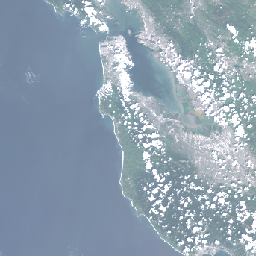

In [ ]:
url = 'https://earthengine.googleapis.com/v1alpha/{}:getPixels'.format(name)
body = json.dumps({
    'fileFormat': 'PNG',
    'bandIds': ['B4', 'B3', 'B2'],
    'region': asset['geometry'],
    'grid': {
        'dimensions': {'width': 256, 'height': 256},
    },
    'visualizationOptions': {
        'ranges': [{'min': 0, 'max': 3000}],
    },
})

image_response = session.post(url, body)
image_content = image_response.content

# Import the Image function from the IPython.display module. 

Image(image_content)

# Authentication with ee library

In [ ]:
# Get some new credentials since the other ones are cloud scope.
ee_creds = ee.ServiceAccountCredentials(SERVICE_ACCOUNT, KEY)
ee.Initialize(ee_creds)

# Image computations with the Earth Engine REST API



In [204]:

coords = [
  # -121.58626826832939, 
  # 38.059141484827485,
  28.034444,
  45.439444,
]
region = ee.Geometry.Point(coords)

collection = ee.ImageCollection('COPERNICUS/S2_HARMONIZED')
collection = collection.filterBounds(region)
collection = collection.filterDate('2020-04-01', '2020-09-01')
image = collection.median()

In [205]:
serialized = ee.serializer.encode(image)

In [214]:
# Make a projection to discover the scale in degrees.
proj = ee.Projection('EPSG:4326').atScale(10).getInfo()

# Get scales out of the transform.
scale_x = proj['transform'][0]
scale_y = -proj['transform'][4]

print('Scale X: %s' % scale_x)
print('Scale Y: %s' % scale_y)

Scale X: 8.983152841195215e-05
Scale Y: -8.983152841195215e-05


In [ ]:


url = 'https://earthengine.googleapis.com/v1beta/projects/{}/image:computePixels'
url = url.format(PROJECT)

response = session.post(
  url=url,
  data=json.dumps({
    'expression': serialized,
    'fileFormat': 'PNG',
    'bandIds': ['B4','B3','B2'],
    'grid': {
      'dimensions': {
        'width': 640,
        'height': 640
      },
      'affineTransform': {
        'scaleX': scale_x,
        'shearX': 0,
        'translateX': coords[0],
        'shearY': 0,
        'scaleY': scale_y,
        'translateY': coords[1]
      },
      'crsCode': 'EPSG:4326',
    },
    'visualizationOptions': {'ranges': [{'min': 0, 'max': 3000}]},
  })
)

image_content_1 = response.content

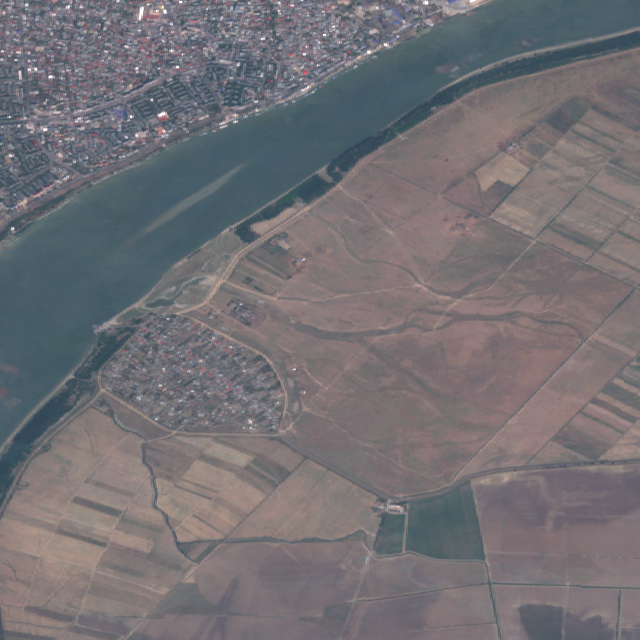

In [ ]:
if response.status_code != 200:
    print(f"Error {response.status_code}: {response.text}")
else:
    
    display(Image(image_content_1))

## Testing to get temperature in Galati, Romania 

As of now I can't get accurate temperature measure from the 'NOAA/CFSR' collection since it has a Pixel Size 55660 meters making it unsuitable for viewing small areas such as a city.

In [223]:
coords = [
  # -121.58626826832939,
  # 38.059141484827485,
  28.034444,
  45.439444,
] # change this to the galati region

region = ee.Geometry.Point(coords)

collection = ee.ImageCollection('NOAA/CFSR')
collection = collection.filterBounds(region)
collection = collection.filterDate('2019-07-17', '2019-07-23')
collection = collection.select('Temperature_surface')
image = collection.mean()


In [224]:
visualized_image = image.visualize(   # Temperature visualization min= 19 C and max= 42 C
    min=292, 
    max=315, 
    palette=['blue', 'purple', 'cyan', 'green', 'yellow', 'red']
)

scale = 20000  # Meters per pixel
# Note: visualized_image produces 3 bands: 'vis-red', 'vis-green', 'vis-blue'

In [225]:
# iamges are taken at 55660 m per pixel
proj = ee.Projection('EPSG:4326').atScale(55660).getInfo()
# proj = ee.Projection('EPSG:4326').atScale(5000).getInfo()
# Get scales out of the transform.
scale_x = proj['transform'][0]
scale_y = -proj['transform'][4]

print('Scale X: %s' % scale_x)
print('Scale Y: %s' % scale_y)

Scale X: 0.5000022871409256
Scale Y: -0.5000022871409256


In [226]:
# Serialize the computation
serialized = ee.serializer.encode(visualized_image)

In [227]:

url = 'https://earthengine.googleapis.com/v1beta/projects/{}/image:computePixels'
url = url.format(PROJECT)

response = session.post(
  url=url,
  data=json.dumps({
    'expression': serialized,
    'fileFormat': 'PNG',
    # We do NOT need 'visualizationOptions' anymore because the image is already RGB.
    'grid': {
      'dimensions': {
        'width': 200,
        'height': 200
      },
      'affineTransform': {
        # 'scaleX': scale / 111319.0,
        'scaleX': scale_x,
        'shearX': 0,
        'translateX': coords[0],
        'shearY': 0,
        # 'scaleY': -scale / 111319.0,
         'scaleY': scale_y,
        'translateY': coords[1]
      },
      'crsCode': 'EPSG:4326',
    }
  })
)


Galati Region Temperature Map:


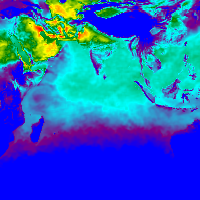

In [228]:
image_content_2 = response.content

if response.status_code != 200:
    print(f"Error {response.status_code}: {response.text}")
else:
    print("Galati Region Temperature Map:")
    display(Image(image_content_2))

# Combinig the two images

Overlay Map (Sentinel-2 + Temperature):


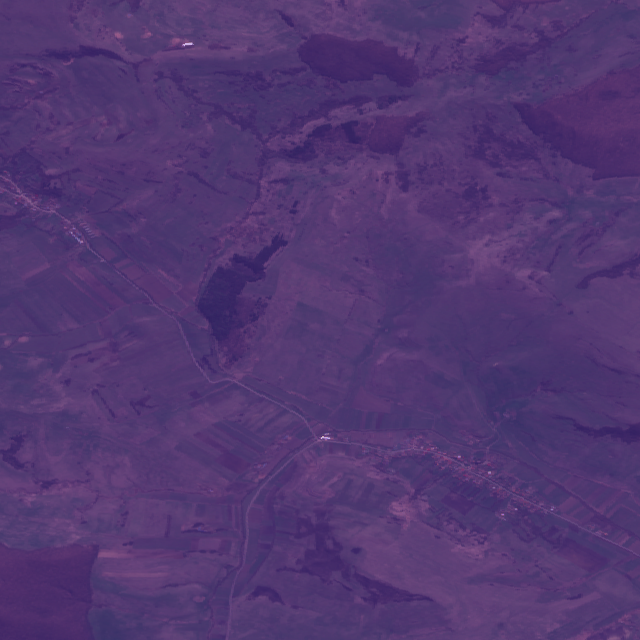

In [ ]:

romania_coords = [ 24.9668, 45.9432,]
region = ee.Geometry.Point(romania_coords)



# sentinel image collection
s2_collection = ee.ImageCollection('COPERNICUS/S2_HARMONIZED') \
    .filterBounds(region) \
    .filterDate('2020-04-01', '2020-04-07')

s2_rgb = s2_collection.median().visualize(
    min=0,
    max=3000,
    bands=['B4', 'B3', 'B2']
)


# temperature image collection
temp_collection = ee.ImageCollection('NOAA/CFSR') \
    .filterBounds(region) \
    .filterDate('2019-07-17T05:00:00', '2019-07-17T23:00:00') \
    .select('Temperature_surface')

temp_rgb = temp_collection.median().visualize(    # Temperature visualization min= 19 C and max= 42 C
    min=292,
    max=315,
    palette=['blue', 'purple', 'cyan', 'green', 'yellow', 'red'],
    opacity=0.3
)


# combining them (server-side overlay)
final_image = s2_rgb.blend(temp_rgb)

# Serialize the FINAL combined image
serialized = ee.serializer.encode(final_image)



scale_meters = 10 

# Calculate the affine transform scale in degrees
proj = ee.Projection('EPSG:4326').atScale(scale_meters).getInfo()
scale_x = proj['transform'][0]
scale_y = proj['transform'][4] # Usually negative in the raw transform


url = 'https://earthengine.googleapis.com/v1beta/projects/{}/image:computePixels'
url = url.format(PROJECT)

response = session.post(
  url=url,
  data=json.dumps({
    'expression': serialized,
    'fileFormat': 'PNG',
    'grid': {
      'dimensions': {
        'width': 640,
        'height': 640
      },
      'affineTransform': {
        'scaleX': scale_x,
        'shearX': 0,
        'translateX': romania_coords[0],
        'shearY': 0,
        'scaleY': scale_y,
        'translateY': romania_coords[1]
      },
      'crsCode': 'EPSG:4326',
    }
  })
)

if response.status_code != 200:
    print(f"Error {response.status_code}: {response.text}")
else:
    print("Overlay Map (Sentinel-2 + Temperature):")
    display(Image(response.content))

# Testing other bands from the same dataset

Overlay Map (Soil Type + Temperature):


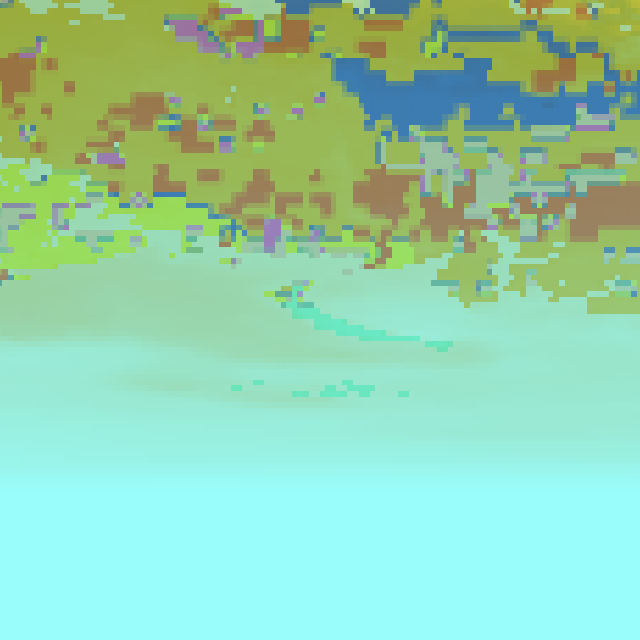

In [ ]:


romania_coords = [28.034444, 45.439444]
region = ee.Geometry.Point(romania_coords)

# --- 2. DATA SELECTION (NOAA/CFSR) ---
# We use the same collection for both Soil and Temperature
noaa_collection = ee.ImageCollection('NOAA/CFSR') \
    .filterBounds(region) \
    .filterDate('2019-04-01', '2019-04-07')

# Prepare Soil Type Layer
soil_type = noaa_collection.select('Soil_type_surface').mean()
soil_visualized = soil_type.visualize(
    min=1,
    max=9,
    palette=['red', 'orange', 'blue', 'yellow', 'violet', 'magenta', 'cadetblue', 'pink', 'aquamarine'],
    opacity=0.6
)

# Prepare Temperature Layer
temp_surface = noaa_collection.select('Temperature_surface').mean()
temp_visualized = temp_surface.visualize(
    min=192,
    max=339,
    palette=['blue', 'purple', 'cyan', 'green', 'yellow', 'red'],
    opacity=0.4 # Keeping it semi-transparent to overlay on soil
)

# --- 3. BLENDING & SERIALIZATION ---
# Blend Temperature on top of Soil Type
final_image = soil_visualized.blend(temp_visualized)

serialized = ee.serializer.encode(final_image)

# --- 4. EXPORT / DISPLAY ---
scale_meters = 10000 # NOAA CFSR is coarse, 10m is too small; 1000m (1km) is more appropriate
proj = ee.Projection('EPSG:4326').atScale(scale_meters).getInfo()
scale_x = proj['transform'][0]
scale_y = proj['transform'][4]

url = f'https://earthengine.googleapis.com/v1beta/projects/{PROJECT}/image:computePixels'

response = session.post(
  url=url,
  data=json.dumps({
    'expression': serialized,
    'fileFormat': 'PNG',
    'grid': {
      'dimensions': {'width': 640, 'height': 640},
      'affineTransform': {
        'scaleX': scale_x,
        'shearX': 0,
        'translateX': romania_coords[0],
        'shearY': 0,
        'scaleY': scale_y,
        'translateY': romania_coords[1]
      },
      'crsCode': 'EPSG:4326',
    }
  })
)

if response.status_code != 200:
    print(f"Error {response.status_code}: {response.text}")
else:
    print("Overlay Map (Soil Type + Temperature):")
    display(Image(response.content))